In [ ]:
from pathlib import Path
import numpy as np
import pynapple as nap
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# bien définir root_path = là où trouver le dossier Spike-sorting qui contient les sous-dossiers Data_folders, Tables, Rasters...
root_path = '/media/aube/Aube2/' #'D:/'
COG = True # est-ce qu'on prend seulement les sessions COG, ou bien tout ?

### IMPORT TABLES
big_df = pd.read_excel(root_path + 'Spike-sorting/Tables/general_summary_all_sessions.xlsx')
df_per_nrn = pd.read_excel(root_path + 'Spike-sorting/Tables/summary_by_nrn_all_sessions.xlsx')

### SPECIAL COG
if COG :
    big_df['sess_folder'] = (big_df['patient'] + '_stim' + big_df['session'].str.extract(r'(\d+)$')[0])
    df_per_nrn['sess_folder'] = (df_per_nrn['patient'] + '_stim' + df_per_nrn['session'].str.extract(r'(\d+)$')[0])
    list_sessions_cog = big_df.dropna(subset=['cog'])['sess_folder'].unique()
    print("Sessions cog:",list_sessions_cog)

    big_df = big_df[big_df['sess_folder'].isin(list_sessions_cog)]
    df_per_nrn = df_per_nrn[df_per_nrn['sess_folder'].isin(list_sessions_cog)]
    for p in df_per_nrn['patient'].unique():
        df_p = df_per_nrn[df_per_nrn['patient']==p]
        for sess in df_p['session'].unique():
            df_p_s = df_p[df_p['session']==sess]
            print(p, sess, 'nrn=', df_p_s.shape[0])
            
big_df_wilcoxon = big_df[big_df['wilcoxon_signif']==True]


### Quelques modifs de variables
# temporaire : fusion de Ant. Hippocampus et Post. Hippocampus en Hippocampus
def antpostHippo2Hippo(df,colname):
    df[colname] = ['Hippocampus' if val.endswith('Hippocampus') else val for val in df[colname].tolist()]
    return df
big_df = antpostHippo2Hippo(big_df,'loca_tt')
big_df = antpostHippo2Hippo(big_df,'loca_tt_noLat')
df_per_nrn = antpostHippo2Hippo(df_per_nrn,'loca_tt')
df_per_nrn = antpostHippo2Hippo(df_per_nrn,'loca_tt_noLat')

# Ajout de la variable elec_noLat (electrode sans la lateralité)
big_df["elec_noLat"] = (
    big_df["stim_label"]
    .str.extract(r"^([A-Za-z']+)", expand=False)  # tout avant les chiffres
    .str.rstrip("p'"))  # enlève p ou ' en fin

# Ajout de log10 des metriques de reponses :
list_metrics = ['log_ratio', 'zscore_pre', 'modulation_index']
for metric in list_metrics:
    big_df[f"log10_{metric}"] = np.log10(big_df[metric])

# Ajout variables de simplification cog :
def cog_recap(row):
    if type(row['cog']) == str or type(row['cog']) == list:
        if row['cog'] == ['controle']:
            return 'ctrl'
        elif row['cog'] == ['negatif']:
            return 'neg'
        else:
            return 'cog'
    else:
        return 'None'
big_df['cog_global'] = big_df.apply(cog_recap, axis=1)

def cog_simplify(c):
    if c=="['deja_vu', 'illusion_perceptive']":
        return 'deja_vu'
    elif c=="['ralentissement_psy', 'deja_vecu']":
        return 'deja_vu'
    elif c=="['aphasie', 'illusion_perceptive']":
        return 'illusion_perceptive'
    elif c=="['deja_vu', 'aphasie']":
        return 'deja_vu'
    elif type(c)==str:
        return c[2:-2]
    else:
        return c

big_df['cog2'] = big_df['cog'].apply(cog_simplify)

# Ajout cog simplifié : 
def cog_group(x):
    if x == "['negatif']":
        return 'Negative'
    elif x == "['controle']":
        return 'Control'
    else:
        return 'Cog+'

big_df['cog_group'] = big_df['cog'].apply(cog_group)


### Preparation des exports:
root_fig = root_path + 'Spike-sorting/Figures/'
if COG:
    root_fig = root_path + 'Spike-sorting/Figures/COG/'
if not os.path.exists(root_fig+'fig_descriptive'): # si le dossier n'existe pas encore, alors on le crée
    os.makedirs(root_fig+'fig_descriptive')
if not os.path.exists(root_fig+'fig_responses'): # si le dossier n'existe pas encore, alors on le crée
    os.makedirs(root_fig+'fig_responses')



df_signif = big_df[big_df['wilcoxon_signif']==True].dropna(subset=['zscore_pre'])
df = big_df

Sessions cog: ['P97_BM50_stim1' 'P101_DC54_stim2' 'P64_BR34_stim2' 'P64_BR34_stim5'
 'P126_VC75_stim1' 'P99_TT52_stim1' 'P102_GC55_stim4' 'P102_GC55_stim5'
 'P101_DC54_stim4' 'P119_FM71_stim1' 'P119_FM71_stim4' 'P127_DS76_stim2'
 'P127_DS76_stim4' 'P127_DS76_stim5' 'P127_DS76_stim6' 'P127_DS76_stim7'
 'P97_BM50_stim4' 'P55_SF27_stim2' 'P106_LL59_stim5' 'P112_MV65_stim1'
 'P107_SG60_stim4' 'P112_MV65_stim3' 'P112_MV65_stim4']
P97_BM50 stimic1 nrn= 12
P97_BM50 stimic4 nrn= 1
P101_DC54 stimic2 nrn= 30
P101_DC54 stimic4 nrn= 10
P64_BR34 stimic2 nrn= 9
P64_BR34 stimic5 nrn= 3
P126_VC75 stimic1 nrn= 1
P99_TT52 stimic1 nrn= 4
P102_GC55 stimic4 nrn= 2
P102_GC55 stimic5 nrn= 1
P119_FM71 stimic1 nrn= 5
P119_FM71 stimic4 nrn= 5
P127_DS76 stimic2 nrn= 24
P127_DS76 stimic4 nrn= 11
P127_DS76 stimic5 nrn= 19
P127_DS76 stimic6 nrn= 12
P127_DS76 stimic7 nrn= 19
P55_SF27 stimic2 nrn= 10
P112_MV65 stimic1 nrn= 32
P112_MV65 stimic4 nrn= 9
P112_MV65 stimic3 nrn= 11
P107_SG60 stimic4 nrn= 8
P106_LL59 stimic

/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/data/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: inval

In [2]:
df_tot = pd.read_excel(root_path + 'Spike-sorting/Tables/general_summary_all_sessions.xlsx') # total : 17 166 essais
big_df # 6598 essais
df_tot

,patient,session,clu,tetrode,lobe_tt,loca_tt,lobe_tt_noLat,loca_tt_noLat,tt_in_ZE,tt_in_ZI,...,inhib_general_0.075s_bins,excit_general_0.075s_bins,inhib_only_0.1s_bins,excit_only_0.1s_bins,inhib_then_excit_0.1s_bins,excit_then_inhib_0.1s_bins,inhib_general_0.1s_bins,excit_general_0.1s_bins,global_clu,Unnamed: 68
0,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
1,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
2,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
3,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
4,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17161,P112_MV65,stimic4,1,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_1,NaN
17162,P112_MV65,stimic4,1,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_1,NaN
17163,P112_MV65,stimic4,1,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_1,NaN
17164,P112_MV65,stimic4,1,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_1,NaN


In [10]:
# total : 17 166 essais (au lieu de 17 642)
mask_snr = df_tot['snr']>2 # 15 551 essais [avec 1541 essais avec SNR<2 : 52 neurones]
mask_isi = df_tot['isi_violations_ratio']<0.01 # 12551 essais [avec 4541 essais avec > 1% : 161 neurones]
mask_presence = df_tot['presence_ratio']>=0.9 # 13077 essais [avec 4015 essais avec < 90% : 131 neurones]

[mask_snr & mask_isi & mask_presence] # 8 534 essais [avec 298 neurones] (au lieu de 7 147)

mask_wilcoxon = df_tot['wilcoxon_signif']==True
df_tot[mask_snr & mask_isi & mask_presence & mask_wilcoxon]  # 1 034 essais [avec 241 neurones] (au lieu de 1 006)


,patient,session,clu,tetrode,lobe_tt,loca_tt,lobe_tt_noLat,loca_tt_noLat,tt_in_ZE,tt_in_ZI,...,inhib_general_0.075s_bins,excit_general_0.075s_bins,inhib_only_0.1s_bins,excit_only_0.1s_bins,inhib_then_excit_0.1s_bins,excit_then_inhib_0.1s_bins,inhib_general_0.1s_bins,excit_general_0.1s_bins,global_clu,Unnamed: 68
14,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
15,P63_AK33,stimic1,0,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_0,NaN
47,P63_AK33,stimic1,2,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_2,NaN
48,P63_AK33,stimic1,2,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_2,NaN
66,P63_AK33,stimic1,2,vsa2,L Frontal,L SMA,Frontal,SMA,True,False,...,0,1,0,1,0,0,0,1,P63_AK33_stimic1_2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17119,P112_MV65,stimic4,0,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_0,NaN
17123,P112_MV65,stimic4,0,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_0,NaN
17127,P112_MV65,stimic4,0,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,1,0,1,0,0,0,1,P112_MV65_stimic4_0,NaN
17130,P112_MV65,stimic4,0,vb2,L. Temporal,L. Ant. Hippocampus,Temporal,Ant. Hippocampus,False,True,...,0,0,0,1,0,0,0,1,P112_MV65_stimic4_0,NaN


In [12]:
# Description du dataset
def decribe_dataset(df, df_nrn):
    nb_sess, nb_stims = 0, 0
    for p in df['patient'].unique():
        for sess in df[df['patient']==p]['session'].unique():
            nb_sess += 1
            nb_clu = len(df[df['patient']==p][df[df['patient']==p]['session']==sess]['clu'].unique())
            nb_stims += df[df['patient']==p][df[df['patient']==p]['session']==sess].shape[0]/nb_clu
    print(f"Dans ce dataset, on a {len(df['patient'].unique())} patients, {int(nb_sess)} sessions, {int(nb_stims)} stims, {df_nrn.shape[0]} units, et {df.shape[0]} trials.")
    print(f"Firing rate de baseline moyen : {round(np.mean(df_nrn['fr_baseline'].tolist()),3)} Hz \nFiring rate de baseline médian : {round(np.median(df_nrn['fr_baseline'].tolist()),3)} Hz")

decribe_dataset(big_df, df_per_nrn)

Dans ce dataset, on a 12 patients, 23 sessions, 700 stims, 242 units, et 6598 trials.
Firing rate de baseline moyen : 1.141 Hz 
Firing rate de baseline médian : 0.314 Hz


##### Distribution globale des z-scores

All trials
KruskalResult(statistic=np.float64(nan), pvalue=np.float64(nan))
Significant trials
KruskalResult(statistic=np.float64(6.640753437399978), pvalue=np.float64(0.03613921487129533))


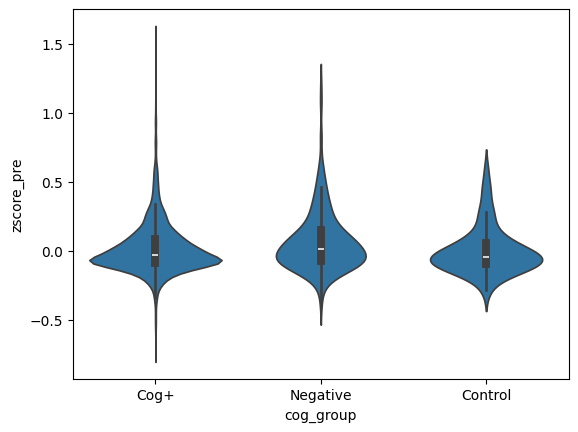

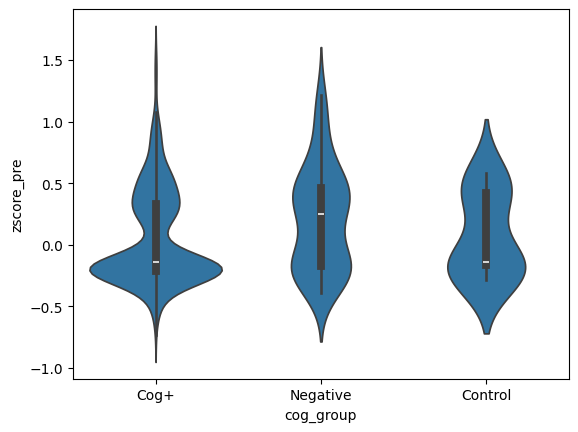

In [48]:
# sur tout :
def violin_CogType(df):
    plt.figure()
    sns.violinplot(
        data=df,
        x='cog_group',
        y='zscore_pre'
    )
    from scipy.stats import kruskal

    groups = [
        df[df['cog_group']=='Cog+']['zscore_pre'],
        df[df['cog_group']=='Control']['zscore_pre'],
        df[df['cog_group']=='Negative']['zscore_pre']
    ]

    print(kruskal(*groups))

print('All trials')
violin_CogType(df)
print('Significant trials')
violin_CogType(df_signif)

#### distance

All trials
local_inf4cm
KruskalResult(statistic=np.float64(10.455145197330642), pvalue=np.float64(0.005366536242122057))
local_elec
KruskalResult(statistic=np.float64(nan), pvalue=np.float64(nan))
local_lobe
KruskalResult(statistic=np.float64(12.854076022984552), pvalue=np.float64(0.0016172339756352356))
controlat
KruskalResult(statistic=np.float64(3.102560637560739), pvalue=np.float64(0.21197640264569598))

Significant trials
local_inf4cm
KruskalResult(statistic=np.float64(1.2196866662411656), pvalue=np.float64(0.5434360008280753))
local_elec
KruskalResult(statistic=np.float64(nan), pvalue=np.float64(nan))
local_lobe
KruskalResult(statistic=np.float64(6.562169880361466), pvalue=np.float64(0.03758745453744845))


/tmp/ipykernel_691/214976609.py:26: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(kruskal(*groups))
/tmp/ipykernel_691/214976609.py:26: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(kruskal(*groups))


controlat
KruskalResult(statistic=np.float64(0.821295394879502), pvalue=np.float64(0.6632205447429798))


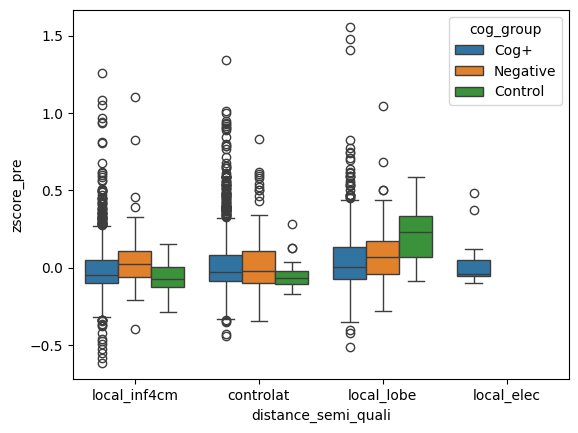

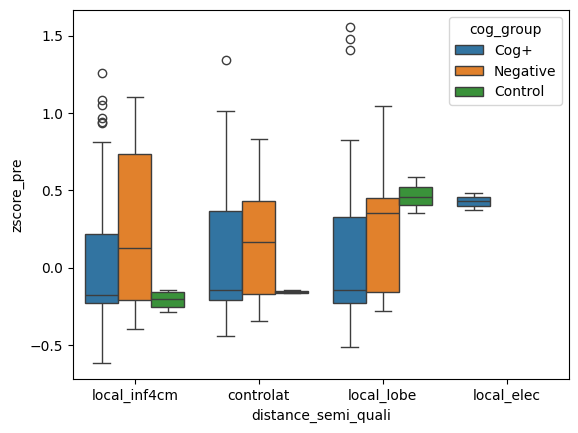

In [11]:
# pour tous les trials
def box_distQuali_CogType(df):
    plt.figure()
    sns.boxplot(
        data=df,
        x='distance_semi_quali',
        y='zscore_pre',
        hue='cog_group'
    )

    from scipy.stats import kruskal
    import scikit_posthocs as sp

    for cat in ['local_inf4cm', 'local_elec', 'local_lobe', 'controlat']:

        sub = df[df['distance_semi_quali']==cat].dropna(subset=['zscore_pre','cog_group'])

        print(cat)

        groups = [
            sub[sub['cog_group']=='Cog+']['zscore_pre'],
            sub[sub['cog_group']=='Control']['zscore_pre'],
            sub[sub['cog_group']=='Negative']['zscore_pre']
        ]

        print(kruskal(*groups))

print('All trials')
box_distQuali_CogType(df)
print('\nSignificant trials')
box_distQuali_CogType(df_signif)

<Figure size 2000x500 with 0 Axes>

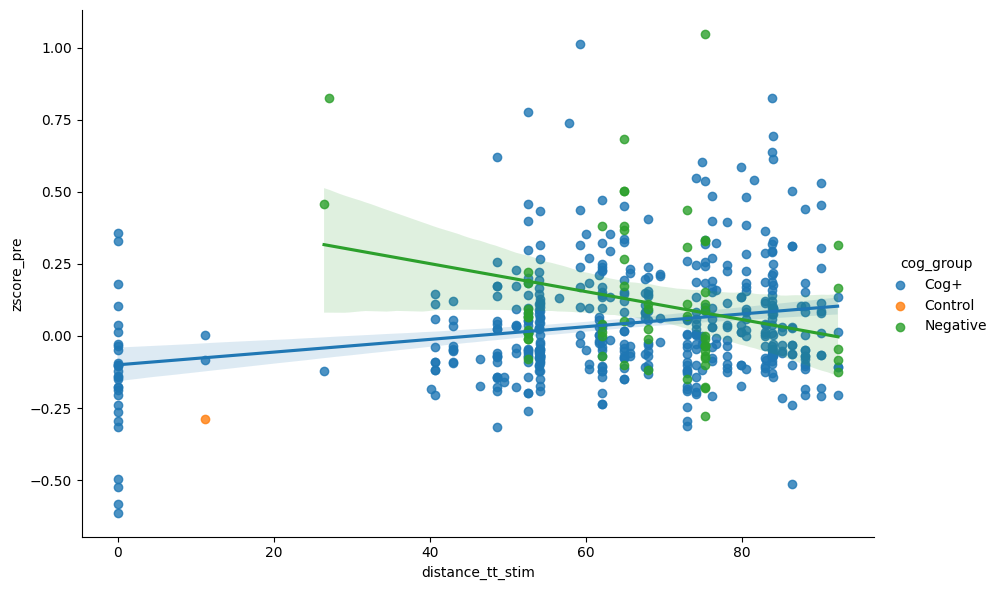

In [62]:
plt.figure(figsize=(20,5))
sns.lmplot(
    data=df[df['loca_tt_noLat']=='Post. Cingulate'],
    x='distance_tt_stim',
    y='zscore_pre',
    hue='cog_group',
    height=6, aspect=1.5
)


In [68]:
from scipy.stats import spearmanr

for grp in df['cog_group'].unique():

    sub = df[df['cog_group']==grp].dropna(subset=['distance_tt_stim', 'zscore_pre'])

    rho,p = spearmanr(
        sub['distance_tt_stim'],
        sub['zscore_pre']
    )

    print(grp, round(rho,3), round(p,3))

Cog+ 0.098 0.0
Negative -0.152 0.021
Control 0.221 0.14


#### Anatomie

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Hippocampus'),
  Text(1, 0, 'Amygdala'),
  Text(2, 0, 'Parahippocampal'),
  Text(3, 0, 'Temporal Pole'),
  Text(4, 0, 'Post. Cingulate')])

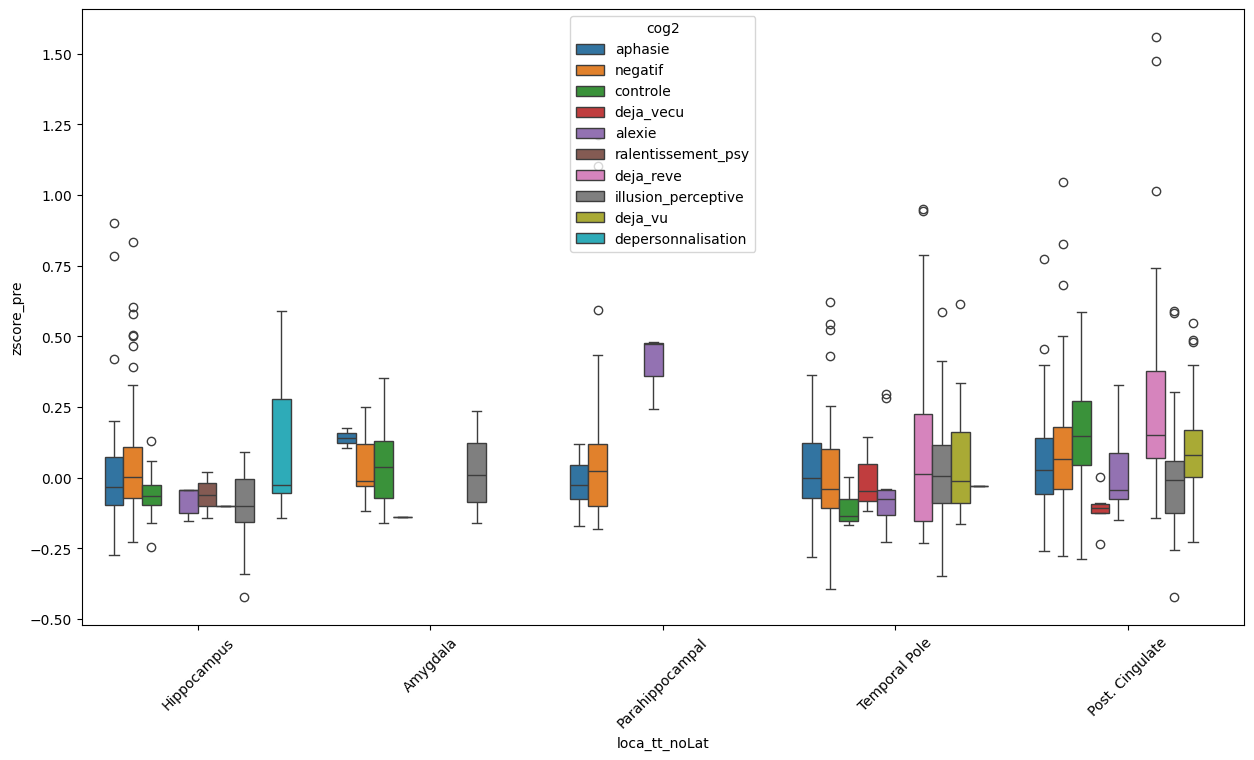

In [116]:
counts = df['loca_tt_noLat'].value_counts()
good_loca = counts[counts>20].index
good_loca_manuel = ['Hippocampus','Temporal Pole', 'Amygdala','Parahippocampal', 'Post. Cingulate']

sub = df[df['loca_tt_noLat'].isin(good_loca_manuel)]

plt.figure(figsize=(15,8))
sns.boxplot(
    data=sub,
    x='loca_tt_noLat',
    y='zscore_pre',
    hue='cog2'
)
plt.xticks(rotation=45)

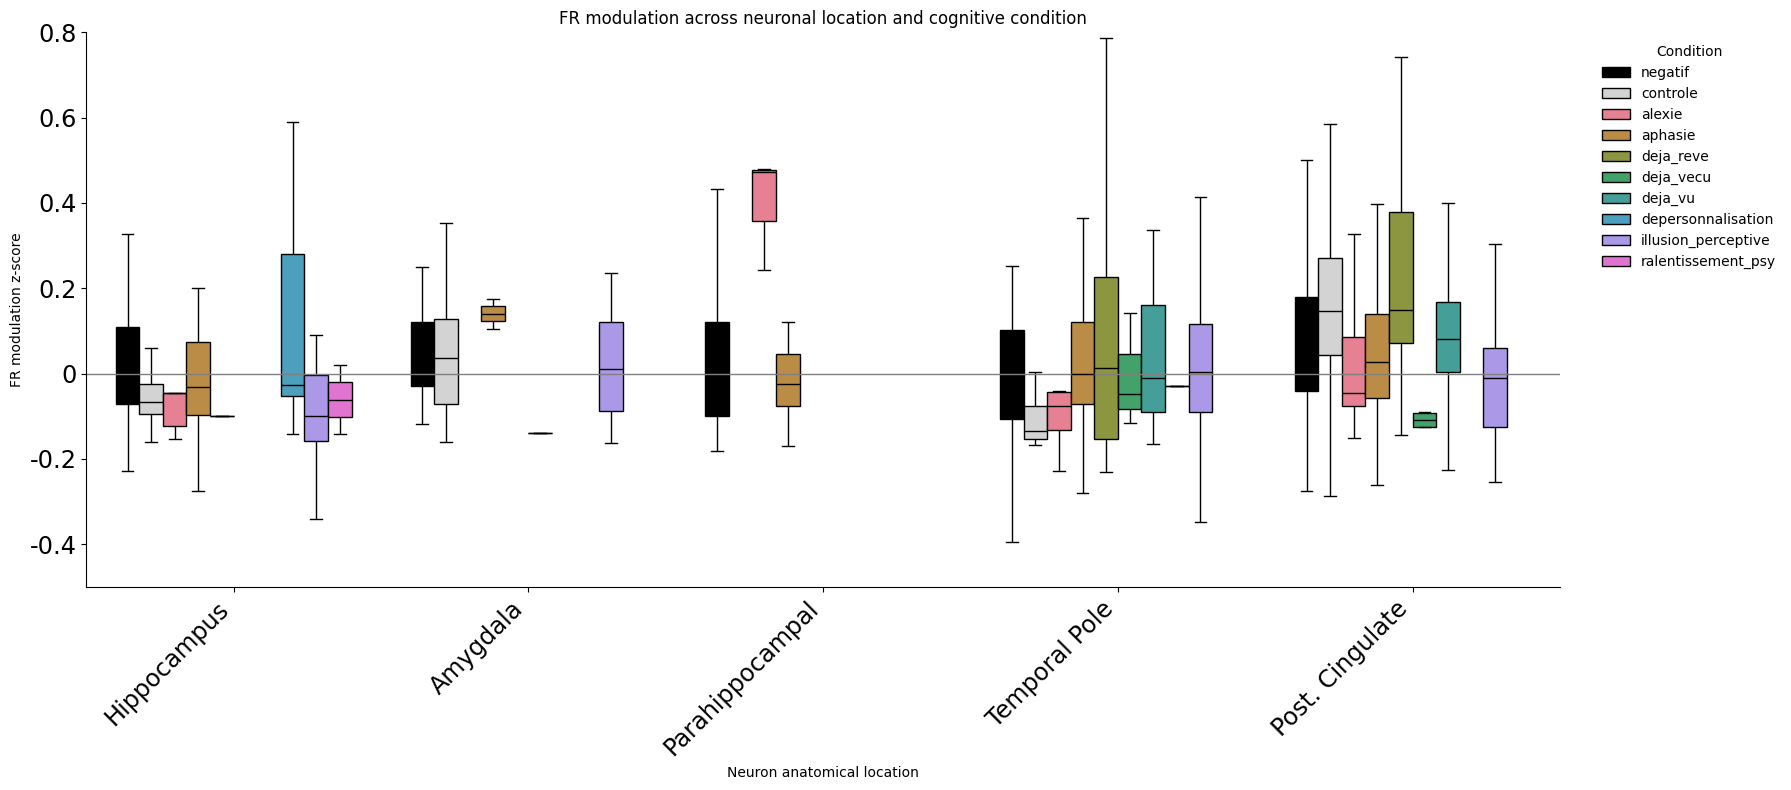

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

good_loca_manuel = [
    'Hippocampus', 'Temporal Pole', 'Amygdala',
    'Parahippocampal', 'Post. Cingulate'
]

sub = df[df['loca_tt_noLat'].isin(good_loca_manuel)].copy()

# ordre des groupes : négatif / contrôle d'abord, puis effets cog
order_hue = ['negatif', 'controle'] + [
    x for x in sorted(sub['cog2'].dropna().unique())
    if x not in ['negatif', 'controle']
]

# palette : négatif et contrôle très distincts, puis spectre pour cog+
cog_effects = [x for x in order_hue if x not in ['negatif', 'controle']]
cog_palette = sns.color_palette("husl", n_colors=len(cog_effects))

palette = {
    'negatif': 'black',
    'controle': 'lightgray',
}
palette.update(dict(zip(cog_effects, cog_palette)))

plt.figure(figsize=(18, 8))

ax = sns.boxplot(
    data=sub,
    x='loca_tt_noLat',
    y='zscore_pre',
    hue='cog2',
    hue_order=order_hue,
    palette=palette,
    showfliers=False)

# points noirs, non ronds : marqueur vertical |
# sns.stripplot(
#     data=sub,
#     x='loca_tt_noLat',
#     y='zscore_pre',
#     hue='cog2',
#     hue_order=order_hue,
#     dodge=True,
#     jitter=0.18,
#     size=3,
#     linewidth=1,
#     color='black',
#     alpha=0.25,
#     ax=ax)

# éviter double légende boxplot + stripplot
handles, labels = ax.get_legend_handles_labels()
n = len(order_hue)
ax.legend(
    handles[:n],
    labels[:n],
    title='Condition',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

# échelle log symétrique : compatible valeurs négatives
# ax.set_yscale('symlog', linthresh=0.1) # linthresh=0.1 définit la zone autour de 0 qui reste linéaire. Mettre 0.2, 0.5 ou 1 si la figure est trop écrasée autour de zéro

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

ax.set_ylim(-0.5, 0.8)
ax.axhline(0, color='grey', linewidth=1)
ax.set_xlabel("Neuron anatomical location")
ax.set_ylabel("FR modulation z-score")
ax.set_title("FR modulation across neuronal location and cognitive condition")

plt.xticks(rotation=45, ha='right', fontsize='xx-large')
plt.yticks(fontsize='xx-large')
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Zscore_LocaAnat_CogType.png', dpi=300)
plt.show()

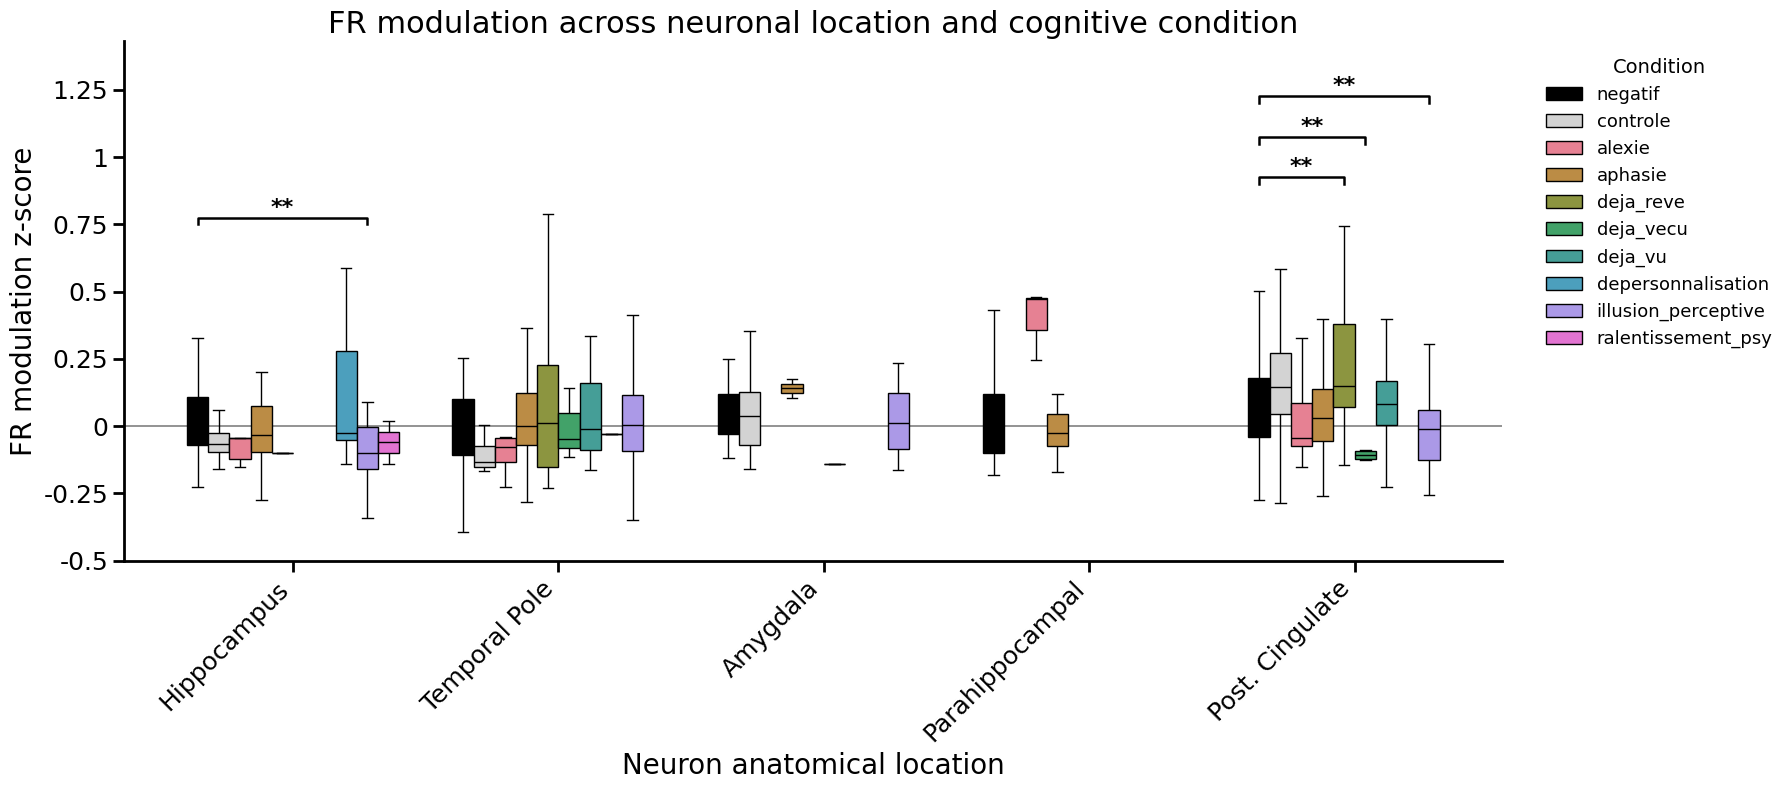

               loca                 cond     p_raw  n_cond  n_ref     p_fdr  \
3       Hippocampus  illusion_perceptive  0.001036      23    104  0.007492   
15  Post. Cingulate            deja_reve  0.001577      39     98  0.007492   
18  Post. Cingulate  illusion_perceptive  0.001573      44     98  0.007492   
16  Post. Cingulate            deja_vecu  0.001552       6     98  0.007492   
13  Post. Cingulate               alexie  0.026538      17     98  0.100843   
11  Parahippocampal               alexie  0.062271       3     25  0.197192   
0       Hippocampus               alexie  0.100178       5    104  0.271912   
5     Temporal Pole              aphasie  0.422315      25     40  0.679178   
12  Parahippocampal              aphasie  0.449937      11     25  0.679178   
14  Post. Cingulate              aphasie  0.464701      34     98  0.679178   
8     Temporal Pole              deja_vu  0.439739      28     40  0.679178   
4     Temporal Pole               alexie  0.423420  

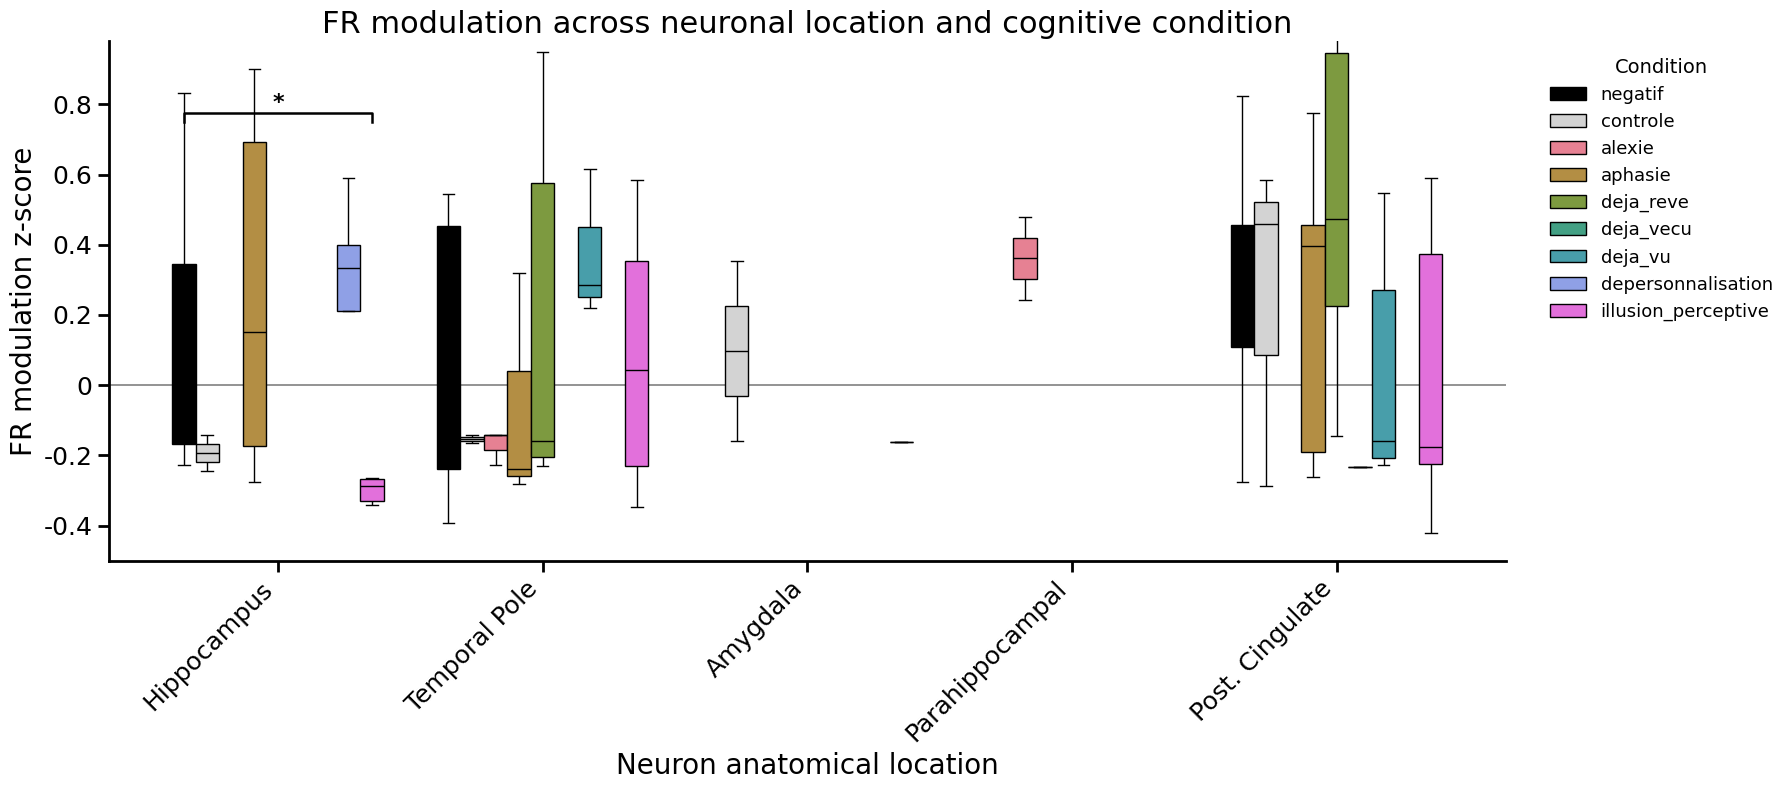

               loca                 cond     p_raw  n_cond  n_ref     p_fdr  \
2       Hippocampus  illusion_perceptive  0.003232       6     12  0.038785   
1       Hippocampus   depersonnalisation  0.261538       4     12  0.557576   
6     Temporal Pole              deja_vu  0.278788       3      8  0.557576   
9   Post. Cingulate            deja_reve  0.238029      10     17  0.557576   
10  Post. Cingulate              deja_vu  0.201096       6     17  0.557576   
11  Post. Cingulate  illusion_perceptive  0.124446       8     17  0.557576   
3     Temporal Pole               alexie  0.473952       3      8  0.812489   
0       Hippocampus              aphasie  0.750269       6     12  0.900323   
4     Temporal Pole              aphasie  0.630303       3      8  0.900323   
5     Temporal Pole            deja_reve  0.734492      12      8  0.900323   
7     Temporal Pole  illusion_perceptive  0.933333       4      8  0.933333   
8   Post. Cingulate              aphasie  0.879547  

In [134]:
def box_LocaAnat_CogTypes(df, dataset=''):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from scipy.stats import mannwhitneyu
    from statsmodels.stats.multitest import multipletests
    from matplotlib.ticker import FuncFormatter

    # ---------- fonctions ----------
    def p_to_stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "ns"

    def add_sig_bar(ax, x1, x2, y, h, text, lw=1.8, fontsize=14):
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color="black", lw=lw, clip_on=False)
        ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
                fontsize=fontsize, fontweight="bold", color="black")

    # ---------- données ----------
    good_loca_manuel = [
        'Hippocampus', 'Temporal Pole', 'Amygdala',
        'Parahippocampal', 'Post. Cingulate'
    ]

    sub = df[df['loca_tt_noLat'].isin(good_loca_manuel)].copy()

    order_x = good_loca_manuel

    order_hue = ['negatif', 'controle'] + [
        x for x in sorted(sub['cog2'].dropna().unique())
        if x not in ['negatif', 'controle']
    ]

    cog_effects = [x for x in order_hue if x not in ['negatif', 'controle']]
    cog_palette = sns.color_palette("husl", n_colors=len(cog_effects))

    palette = {
        'negatif': 'black',
        'controle': 'lightgray',
    }
    palette.update(dict(zip(cog_effects, cog_palette)))

    # ---------- tests : dans chaque localisation, chaque cog vs negatif ----------
    tests = []

    for loca in order_x:
        sub_loca = sub[sub['loca_tt_noLat'] == loca]

        y_ref = sub_loca.loc[sub_loca['cog2'] == 'negatif', 'zscore_pre'].dropna()

        for cond in cog_effects:  # cog+ uniquement, pas controle
            y_cond = sub_loca.loc[sub_loca['cog2'] == cond, 'zscore_pre'].dropna()

            if len(y_ref) >= 3 and len(y_cond) >= 3:
                stat, p = mannwhitneyu(y_cond, y_ref, alternative='two-sided')
                tests.append({
                    'loca': loca,
                    'cond': cond,
                    'p_raw': p,
                    'n_cond': len(y_cond),
                    'n_ref': len(y_ref)
                })

    tests_df = pd.DataFrame(tests)

    if len(tests_df) > 0:
        reject, p_corr, _, _ = multipletests(tests_df['p_raw'], method='fdr_bh')
        tests_df['p_fdr'] = p_corr
        tests_df['reject_fdr'] = reject
    else:
        tests_df['p_fdr'] = []
        tests_df['reject_fdr'] = []

    sig_tests = tests_df[tests_df['reject_fdr']].copy()

    # ---------- plot ----------
    plt.figure(figsize=(18, 8))

    plt.axhline(0, color='grey', linewidth=1.2)

    ax = sns.boxplot(
        data=sub,
        x='loca_tt_noLat',
        y='zscore_pre',
        hue='cog2',
        order=order_x,
        hue_order=order_hue,
        palette=palette,
        showfliers=False,
        # linewidth=1
    )

    handles, labels = ax.get_legend_handles_labels()
    n = len(order_hue)
    ax.legend(
        handles[:n],
        labels[:n],
        title='Condition',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=False,
        fontsize=13,
        title_fontsize=14
    )

    # ---------- ticks renforcés ----------
    ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=8, color='black')
    ax.tick_params(axis='both', which='minor', width=1.5, length=4, color='black')

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(2)
        ax.spines[spine].set_color('black')

    # ---------- barres significativité ----------
    # positions approximatives des box hue dans seaborn
    n_hue = len(order_hue)
    box_width = 0.8
    hue_step = box_width / n_hue

    ymin, ymax = -0.5, 0.8
    ax.set_ylim(ymin, ymax)

    bar_h = 0.025
    base_y = 0.75
    step_y = 0.15

    for i, (_, row) in enumerate(sig_tests.iterrows()):
        x_center = order_x.index(row['loca'])

        idx_ref = order_hue.index('negatif')
        idx_cond = order_hue.index(row['cond'])

        x_ref = x_center - box_width/2 + hue_step/2 + idx_ref * hue_step
        x_cond = x_center - box_width/2 + hue_step/2 + idx_cond * hue_step

        y = base_y + i * step_y
        add_sig_bar(
            ax,
            x_ref,
            x_cond,
            y,
            bar_h,
            p_to_stars(row['p_fdr']),
            fontsize=16
        )

    # élargir ylim pour laisser la place aux barres
    if len(sig_tests) > 0:
        ax.set_ylim(ymin, base_y + len(sig_tests) * step_y + 0.08)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

    
    ax.set_xlabel("Neuron anatomical location", fontsize=20)
    ax.set_ylabel("FR modulation z-score", fontsize=20)
    ax.set_title("FR modulation across neuronal location and cognitive condition", fontsize=22)

    plt.xticks(rotation=45, ha='right', fontsize=18)
    plt.yticks(fontsize=18)

    sns.despine()
    plt.tight_layout()

    plt.savefig(root_fig + f'fig_responses/Zscore_LocaAnat_CogType_sig{dataset}.png', dpi=600, bbox_inches='tight')
    plt.show()

    print(tests_df.sort_values("p_fdr"))

box_LocaAnat_CogTypes(df, dataset='')
box_LocaAnat_CogTypes(df_signif, dataset='_wilcoxon')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Hippocampus'),
  Text(1, 0, 'Amygdala'),
  Text(2, 0, 'Parahippocampal'),
  Text(3, 0, 'Post. Cingulate'),
  Text(4, 0, 'Temporal Pole')])

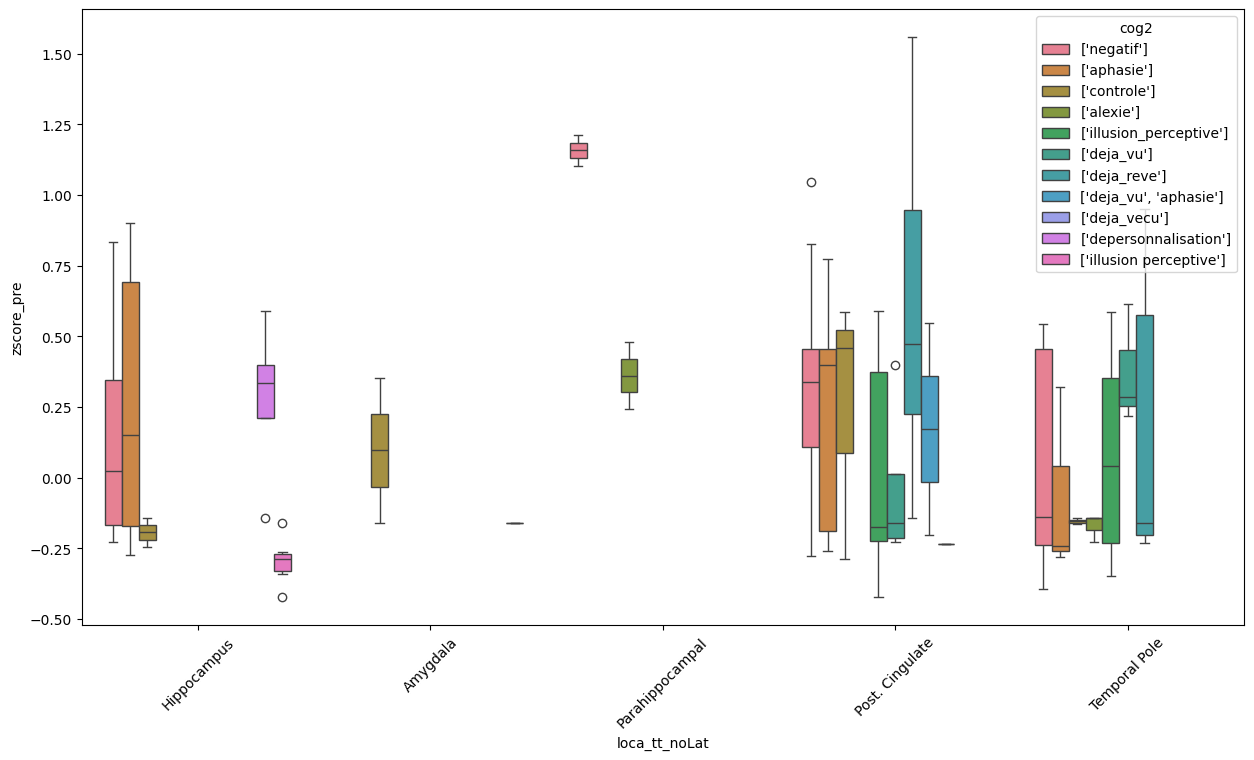

In [90]:
counts = df_signif['loca_tt_noLat'].value_counts()
good_loca = counts[counts>20].index
good_loca_manuel = ['Hippocampus','Temporal Pole', 'Amygdala','Parahippocampal', 'Post. Cingulate']

sub = df_signif[df_signif['loca_tt_noLat'].isin(good_loca_manuel)]

plt.figure(figsize=(15,8))
sns.boxplot(
    data=sub,
    x='loca_tt_noLat',
    y='zscore_pre',
    hue='cog2'
)
plt.xticks(rotation=45)

In [91]:
import statsmodels.formula.api as smf

model = smf.ols(
    'zscore_pre ~ cog_group + C(loca_tt_noLat) + distance_tt_stim + fr_baseline',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             zscore_pre   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     7.256
Date:               mer., 20 mai 2026   Prob (F-statistic):           6.51e-17
Time:                        20:11:58   Log-Likelihood:                 1015.4
No. Observations:                3439   AIC:                            -1997.
Df Residuals:                    3422   BIC:                            -1892.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [93]:
# interaction simple
model = smf.ols(
    'zscore_pre ~ cog_group * distance_tt_stim',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             zscore_pre   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     9.126
Date:               mer., 20 mai 2026   Prob (F-statistic):           1.23e-08
Time:                        20:13:24   Log-Likelihood:                 980.73
No. Observations:                3439   AIC:                            -1949.
Df Residuals:                    3433   BIC:                            -1913.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

#### FR baseline

Cog+ 0.132 0.0
Negative 0.2 0.0
Control 0.188 0.147


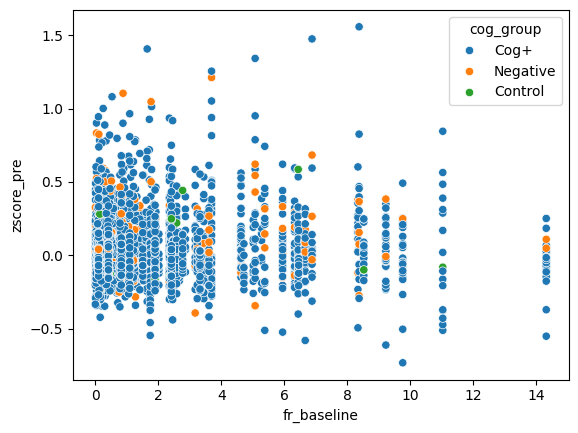

In [99]:
sns.scatterplot(
    data=df,
    x='fr_baseline',
    y='zscore_pre',
    hue='cog_group'
)

for grp in df['cog_group'].unique():

    sub = df[df['cog_group']==grp].dropna(subset=['fr_baseline', 'zscore_pre'])

    rho,p = spearmanr(
        sub['fr_baseline'],
        sub['zscore_pre']
    )

    print(grp, round(rho,3), round(p,3))

Cog+
Negative
Control


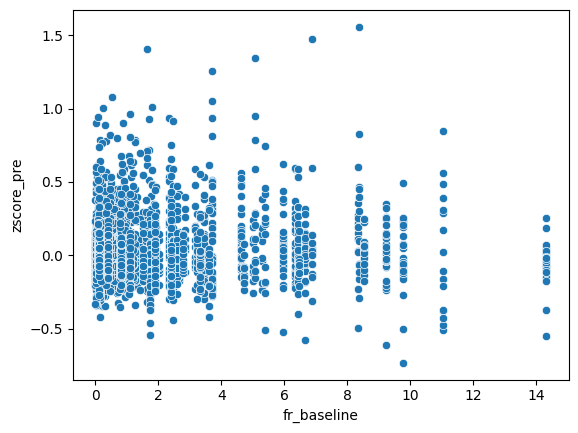

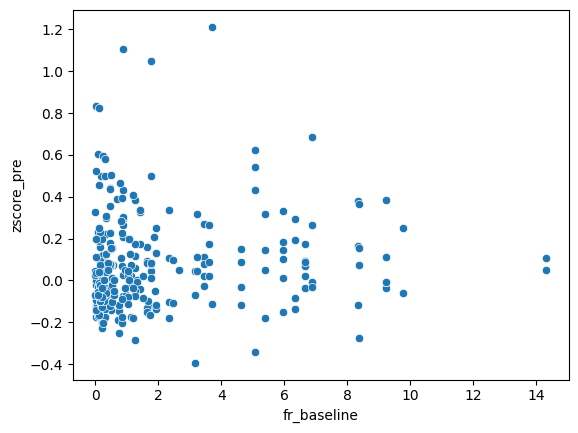

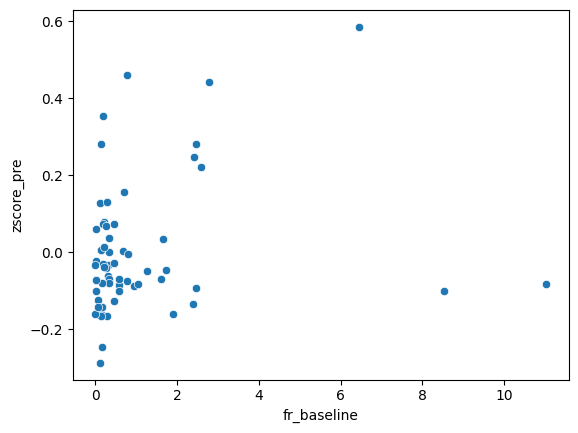

In [101]:
for grp in df['cog_group'].unique():
    plt.figure()
    print(grp)
    sub = df[df['cog_group']==grp].dropna(subset=['fr_baseline', 'zscore_pre'])
    sns.scatterplot(
        data=sub,
        x='fr_baseline',
        y='zscore_pre'
    )

#### Modele général

In [103]:
model = smf.ols(
    '''
    zscore_pre ~
    cog_group
    + distance_tt_stim
    + C(distance_semi_quali)
    + C(loca_tt_noLat)
    + fr_baseline
    + cog_group:distance_tt_stim
    ''',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             zscore_pre   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     4.973
Date:               mer., 20 mai 2026   Prob (F-statistic):           8.72e-13
Time:                        20:19:33   Log-Likelihood:                 881.21
No. Observations:                2934   AIC:                            -1718.
Df Residuals:                    2912   BIC:                            -1587.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

#### Network-level

In [20]:
dict_CogType2Loca = {'alexie':['Parahippocampal'], 
                     'aphasie':['Amygdala', 'Hippocampus', 'Parahippocampal'], 
                     'deja_reve':['Hippocampus'],
                     'deja_vecu':['Hippocampus', 'Temporal Pole', 'Parahippocampal'],
                     'deja_vu':['Amygdala', 'Hippocampus', 'Temporal Pole', 'Parahippocampal'],
                    #  'depersonnalisation':['Hippocampus'],
                     'illusion_perceptive':['Post. Cingulate', 'Hippocampus', 'Parahippocampal'], 
                     'ralentissement_psy':['Hippocampus']}


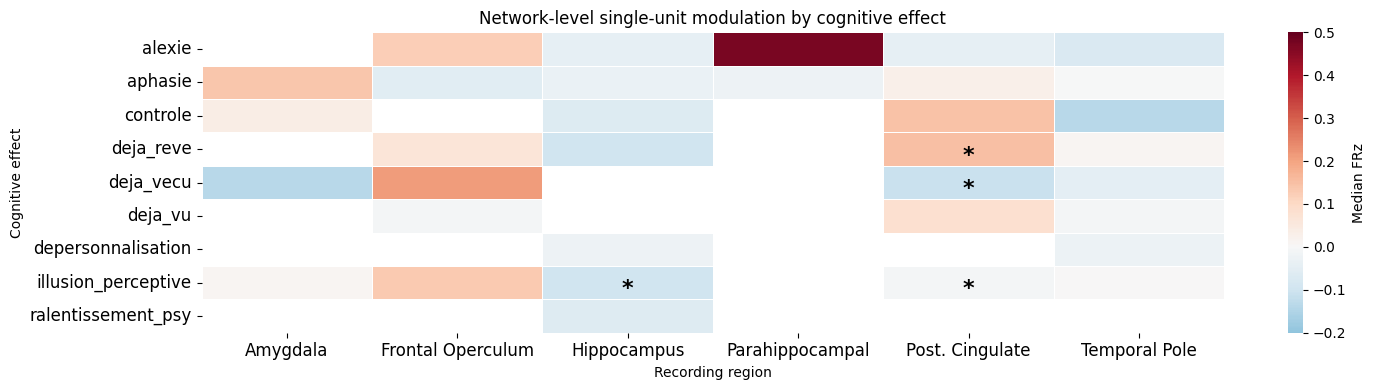

                   cog2      loca_tt_noLat     p_raw  n_cog  n_neg     p_fdr  \
14            deja_reve    Post. Cingulate  0.001577     39     98  0.010647   
25  illusion_perceptive    Post. Cingulate  0.001573     44     98  0.010647   
24  illusion_perceptive        Hippocampus  0.001036     23    104  0.010647   
16            deja_vecu    Post. Cingulate  0.001552      6     98  0.010647   
10             controle        Hippocampus  0.011979     22    104  0.064687   
2                alexie    Post. Cingulate  0.026538     17     98  0.119419   
12             controle      Temporal Pole  0.032621      7     40  0.125824   
1                alexie    Parahippocampal  0.062271      3     25  0.210165   
23  illusion_perceptive  Frontal Operculum  0.098026      6     16  0.270481   
0                alexie        Hippocampus  0.100178      5    104  0.270481   
6               aphasie    Parahippocampal  0.449937     11     25  0.660364   
8               aphasie      Temporal Po

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -----------------------------
# 1) Matrice median_z
# -----------------------------
df_cog = df[df['loca_tt_noLat'].isin(['Hippocampus','Amygdala', 'Parahippocampal', 'Temporal Pole', 'Frontal Operculum', 'Post. Cingulate'])]

network_by_cog = (
    df_cog[df_cog['cog2'] != 'negatif']
    .groupby(['cog2', 'loca_tt_noLat'])
    .agg(
        median_z=('zscore_pre', 'median'),
        n=('zscore_pre', 'size')
    )
    .reset_index()
)

mat = network_by_cog.pivot(
    index='cog2',
    columns='loca_tt_noLat',
    values='median_z'
)

# -----------------------------
# 2) Tests cog2 vs negatif
#    pour chaque localisation
# -----------------------------
tests = []

for cog in mat.index:
    for loca in mat.columns:

        y_cog = df.loc[
            (df['cog2'] == cog) &
            (df['loca_tt_noLat'] == loca),
            'zscore_pre'
        ].dropna()

        y_neg = df.loc[
            (df['cog2'] == 'negatif') &
            (df['loca_tt_noLat'] == loca),
            'zscore_pre'
        ].dropna()

        if len(y_cog) >= 3 and len(y_neg) >= 3:
            stat, p = mannwhitneyu(
                y_cog,
                y_neg,
                alternative='two-sided'
            )

            tests.append({
                'cog2': cog,
                'loca_tt_noLat': loca,
                'p_raw': p,
                'n_cog': len(y_cog),
                'n_neg': len(y_neg)
            })

tests_df = pd.DataFrame(tests)

# -----------------------------
# 3) Correction FDR
# -----------------------------
tests_df['p_fdr'] = np.nan
tests_df['signif'] = False

if len(tests_df) > 0:
    reject, p_corr, _, _ = multipletests(
        tests_df['p_raw'],
        method='fdr_bh'
    )
    tests_df['p_fdr'] = p_corr
    tests_df['signif'] = reject

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# matrice d’annotation avec astérisques uniquement
stars = pd.DataFrame('', index=mat.index, columns=mat.columns)

for _, row in tests_df.iterrows():
    if row['signif']:
        stars.loc[row['cog2'], row['loca_tt_noLat']] = p_to_stars(row['p_fdr'])

# -----------------------------
# 4) Heatmap avec astérisques
# -----------------------------
plt.figure(figsize=(15, 4))

ax = sns.heatmap(
    mat,
    cmap='RdBu_r',
    center=0,
    vmin=-0.2,
    vmax=0.5,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Median FRz'}
)

# ajout manuel des étoiles
for i, cog in enumerate(mat.index):
    for j, loca in enumerate(mat.columns):

        star = stars.loc[cog, loca]

        if star != '':
            ax.text(
                j + 0.5,
                i + 0.7,   # <-- ajustement hauteur des étoiles (augmenter la valeur pour les abaisser)
                star,
                ha='center',
                va='center',
                fontsize=16,
                fontweight='bold',
                color='black'
            )

ax.set_title("Network-level single-unit modulation by cognitive effect")
ax.set_xlabel("Recording region")
ax.set_ylabel("Cognitive effect")

plt.xticks( fontsize='large') #rotation=45, ha='right')
plt.yticks(rotation=0, fontsize='large')

plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Network_modulation_by_CogType.png', dpi=800)
plt.show()

print(tests_df.sort_values('p_fdr'))

#### Distrib zscore

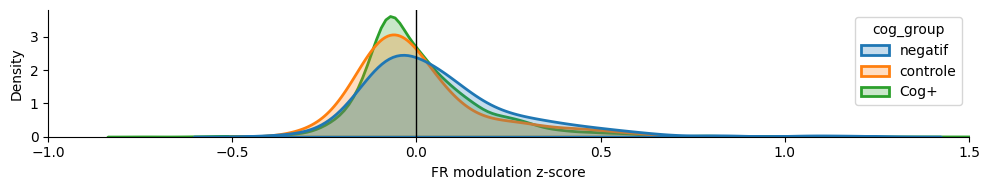

In [6]:
# distributions globales de zscore_pre

df_plot = df.copy()

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xlabel("FR modulation z-score")
plt.ylabel("Density")
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType.png', dpi=400)
plt.show()

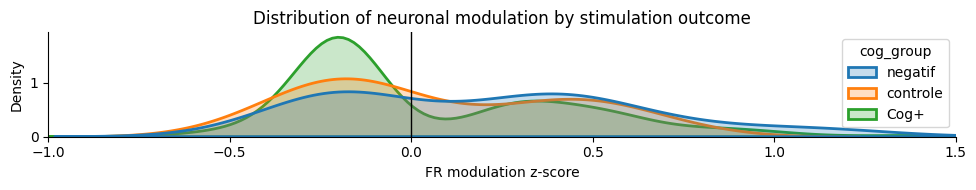

In [7]:
# distributions globales de zscore_pre, signif

df_plot = df_signif.copy()

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2)

plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xlabel("FR modulation z-score")
plt.ylabel("Density")
plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_signif.png', dpi=400)
plt.show()

/tmp/ipykernel_988/184620955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


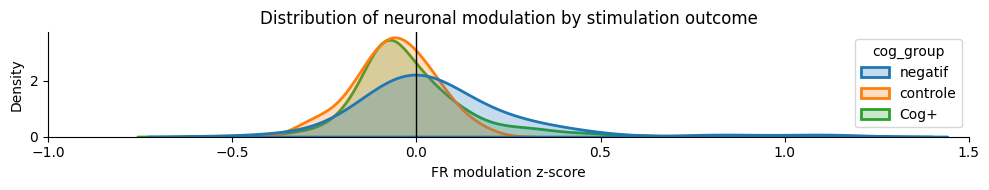

In [8]:
# distributions globales de zscore_pre : local_inf4cm

df_plot = df[df['distance_semi_quali']=='local_inf4cm']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xlabel("FR modulation z-score")
plt.ylabel("Density")
plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_inf4cm.png', dpi=400)
plt.show()

/tmp/ipykernel_988/3076176502.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


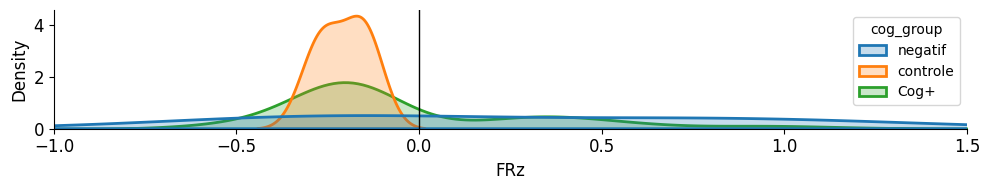

In [19]:
# distributions globales de zscore_pre : local_inf4cm, signif

df_plot = df_signif[df_signif['distance_semi_quali']=='local_inf4cm']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_inf4cm_signif.png', dpi=400)
plt.show()

/tmp/ipykernel_988/2370788020.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


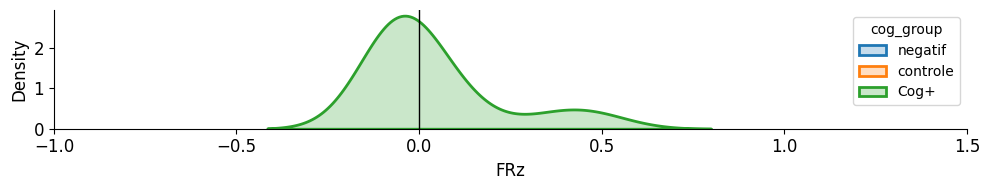

In [20]:
# distributions globales de zscore_pre : local_elec

df_plot = df[df['distance_semi_quali']=='local_elec']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_elec.png', dpi=400)
plt.show()

/tmp/ipykernel_988/3050494758.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


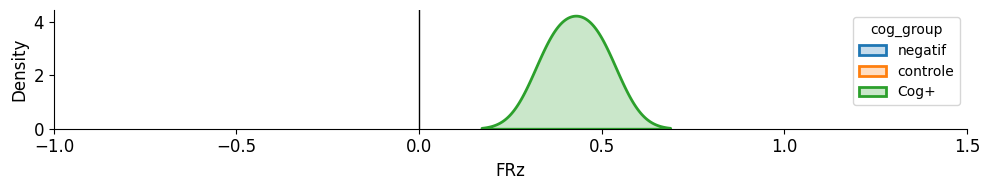

In [21]:
# distributions globales de zscore_pre : local_elec, signif

df_plot = df_signif[df_signif['distance_semi_quali']=='local_elec']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_elec_signif.png', dpi=400)
plt.show()

/tmp/ipykernel_988/3812226095.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


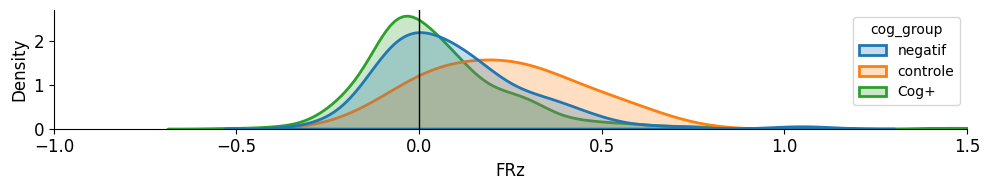

In [22]:
# distributions globales de zscore_pre : local_lobe

df_plot = df[df['distance_semi_quali']=='local_lobe']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_lobe.png', dpi=400)
plt.show()

/tmp/ipykernel_988/2009055233.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


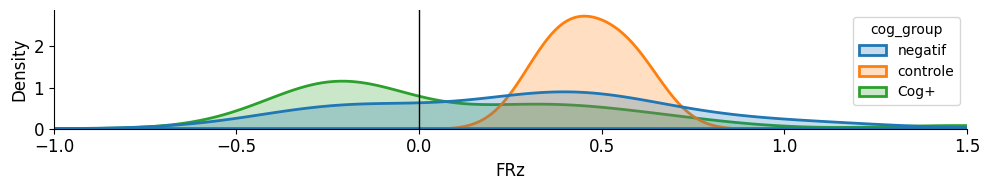

In [23]:
# distributions globales de zscore_pre : local_lobe, signif

df_plot = df_signif[df_signif['distance_semi_quali']=='local_lobe']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_local_lobe_signif.png', dpi=400)
plt.show()

/tmp/ipykernel_988/3056916221.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


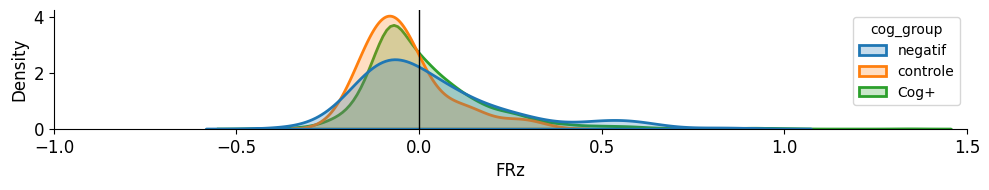

In [24]:
# distributions globales de zscore_pre : controlat

df_plot = df[df['distance_semi_quali']=='controlat']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_controlat.png', dpi=400)
plt.show()

/tmp/ipykernel_988/2168125081.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['cog_group'] = np.where(


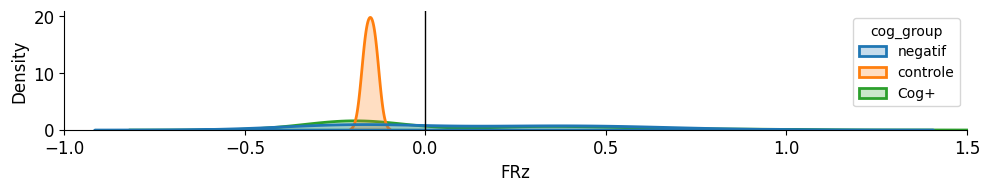

In [25]:
# distributions globales de zscore_pre : controlat, signif

df_plot = df_signif[df_signif['distance_semi_quali']=='controlat']

df_plot['cog_group'] = np.where(
    df_plot['cog2'].isin(['negatif', 'controle']),
    df_plot['cog2'],
    'Cog+'
)

order_group = ['negatif', 'controle', 'Cog+']

plt.figure(figsize=(10,2))
sns.kdeplot(
    data=df_plot,
    x='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2
)
plt.axvline(0, color='k', lw=1)
plt.xlim(-1,1.5)
plt.xticks(fontsize='large')
plt.yticks(fontsize='large')
plt.xlabel("FRz", fontsize='large')
plt.ylabel("Density", fontsize='large')
# plt.title("Distribution of neuronal modulation by stimulation outcome")
sns.despine()
plt.tight_layout()
plt.savefig(root_fig+'fig_responses/Distrib_zscore_CogType_controlat_signif.png', dpi=400)
plt.show()

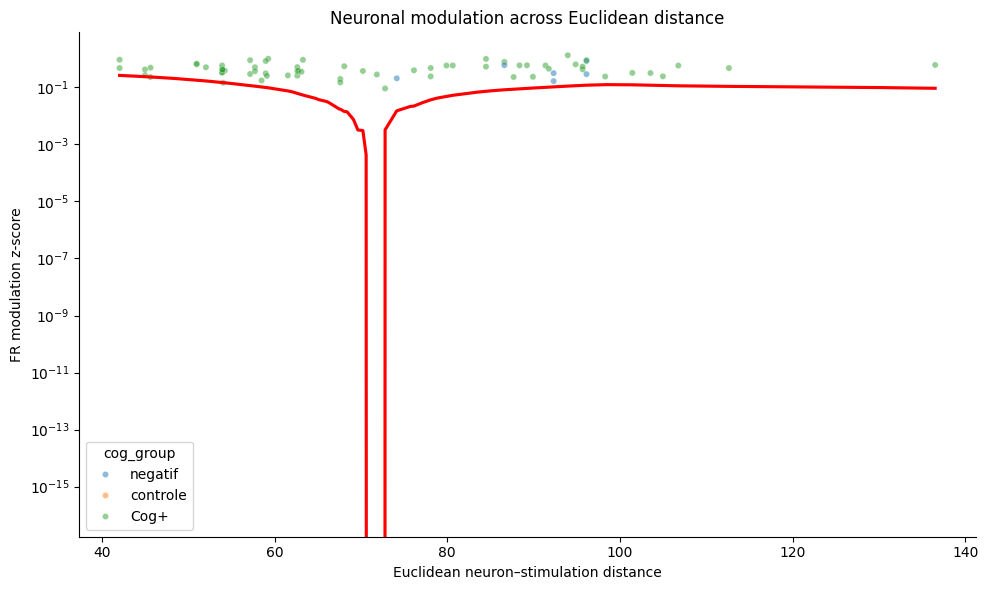

In [27]:
# Distance continue : scatter

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_plot,
    x='distance_tt_stim',
    y='zscore_pre',
    hue='cog_group',
    hue_order=order_group,
    alpha=0.5,
    s=20
)

sns.regplot(
    data=df_plot[df_plot['cog_group']=='Cog+'],
    x='distance_tt_stim',
    y='zscore_pre',
    lowess=True,
    scatter=False,
    color='red',
    label='Cog+ trend'
)

plt.axhline(0, color='k', lw=1)
plt.yscale('log')
plt.xlabel("Euclidean neuron–stimulation distance")
plt.ylabel("FR modulation z-score")
plt.title("Neuronal modulation across Euclidean distance")
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2391/2233314158.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['cog_group', 'dist_bin'])
/var/data/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/var/data/python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


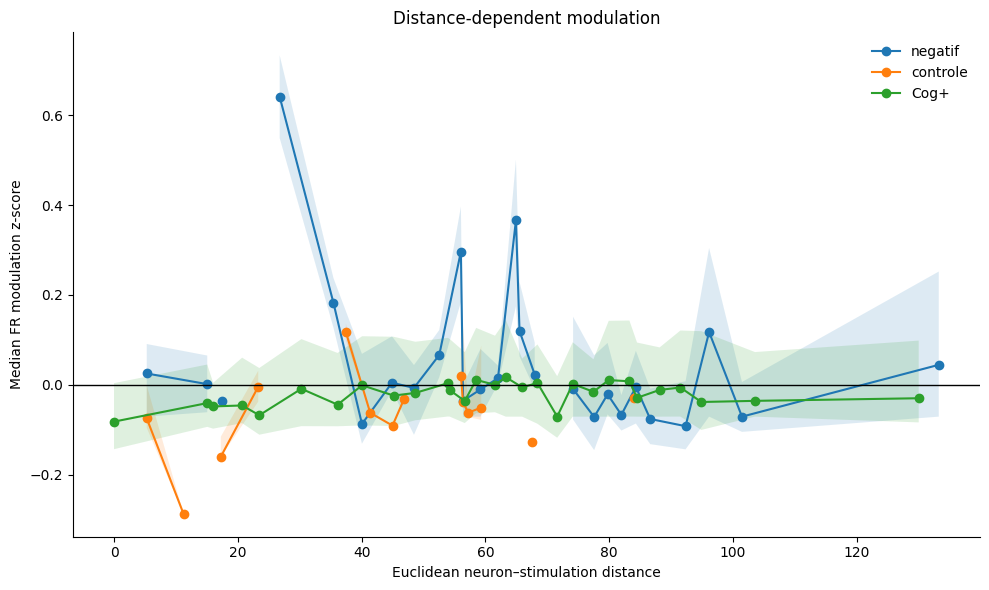

In [65]:
# Distance continue : binning

df_plot['dist_bin'] = pd.qcut(
    df_plot['distance_tt_stim'],
    q=30,
    duplicates='drop'
)

dist_summary = (
    df_plot
    .groupby(['cog_group', 'dist_bin'])
    .agg(
        median_z=('zscore_pre', 'median'),
        q25=('zscore_pre', lambda x: np.nanpercentile(x, 25)),
        q75=('zscore_pre', lambda x: np.nanpercentile(x, 75)),
        dist_mid=('distance_tt_stim', 'median'),
        n=('zscore_pre', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(10,6))

for g in order_group:
    subg = dist_summary[dist_summary['cog_group'] == g]
    plt.plot(subg['dist_mid'], subg['median_z'], marker='o', label=g)
    plt.fill_between(subg['dist_mid'], subg['q25'], subg['q75'], alpha=0.15)

plt.axhline(0, color='k', lw=1)
plt.xlabel("Euclidean neuron–stimulation distance")
plt.ylabel("Median FR modulation z-score")
plt.title("Distance-dependent modulation")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2391/4249261888.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


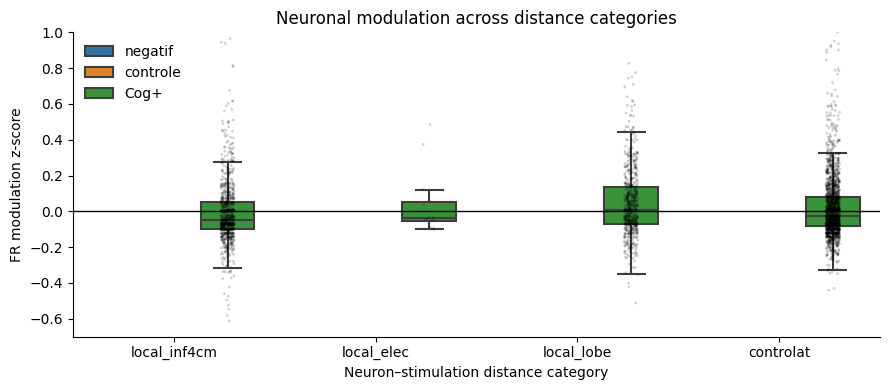

In [91]:
# Distance semi-quali

dist_order = ['local_inf4cm', 'local_elec', 'local_lobe', 'controlat']

sub_dist = df[df['distance_semi_quali'].isin(dist_order)].copy()

plt.figure(figsize=(9,4))

sns.boxplot(
    data=sub_dist,
    x='distance_semi_quali',
    y='zscore_pre',
    hue='cog_group',
    order=dist_order,
    hue_order=order_group,
    showfliers=False,
    linewidth=1.5
)

sns.stripplot(
    data=sub_dist,
    x='distance_semi_quali',
    y='zscore_pre',
    hue='cog_group',
    order=dist_order,
    hue_order=order_group,
    dodge=True,
    color='black',
    alpha=0.18,
    size=2
)

# éviter double légende
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(order_group)], labels[:len(order_group)], frameon=False)

plt.axhline(0, color='k', lw=1)
plt.ylim(-0.7, 1)
plt.xlabel("Neuron–stimulation distance category")
plt.ylabel("FR modulation z-score")
plt.title("Neuronal modulation across distance categories")
sns.despine()
plt.tight_layout()
plt.show()